In [9]:
%pip install pronouncing sentence-transformers torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 24.5 MB/s eta 0:00:00


In [10]:
import re, io, csv, math, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from google.colab import files
from sentence_transformers import SentenceTransformer, util
import pronouncing

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
# Automatically uses GPU if available (Colab provides a free T4)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Hyperparameters ───────────────────────────────────────────────────────────
MAX_LEN    = 30     # max sequence length (words)
EMBED_DIM  = 128    # word embedding size
HIDDEN_DIM = 256    # GRU hidden state size
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 0.001
CLIP       = 1.0    # gradient clipping to prevent exploding gradients
TEACHER_FORCING_RATIO = 0.5  # probability of using ground truth token during training

print('Config ready.')

Using device: cuda
Config ready.


In [11]:
import pandas as pd
import io # edits to imports here
import random
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))

pairs = list(zip(df['input'].tolist(), df['target'].tolist()))
random.shuffle(pairs)

# Train / val / test split — split on unique targets so no target leaks across splits
unique_targets = list({t for _, t in pairs})
random.shuffle(unique_targets)
n = len(unique_targets)
train_targets = set(unique_targets[:int(n * 0.8)])
val_targets   = set(unique_targets[int(n * 0.8):int(n * 0.9)])
test_targets  = set(unique_targets[int(n * 0.9):])

train_pairs = [(s, t) for s, t in pairs if t in train_targets]
val_pairs   = [(s, t) for s, t in pairs if t in val_targets]
test_pairs  = [(s, t) for s, t in pairs if t in test_targets]

print(f'Total pairs : {len(pairs):,}')
print(f'Train       : {len(train_pairs):,}')
print(f'Val         : {len(val_pairs):,}')
print(f'Test        : {len(test_pairs):,}')
print(f'\nExample:')
print(f'  INPUT  : {pairs[0][0]}')
print(f'  TARGET : {pairs[0][1]}')

Saving training_pairs.csv to training_pairs (3).csv
Total pairs : 1,455
Train       : 1,164
Val         : 144
Test        : 147

Example:
  INPUT  : Tan sacred beauty doth blunt the sharpest intents, that which is most hallowed in appearance.
  TARGET : Tan sacred beauty, blunt the sharpest intents,


In [12]:
def tokenize(text):
    """Lowercase, strip punctuation, split into word tokens."""
    return re.sub(r"[^a-zA-Z\s]", "", text.lower()).split()


def build_vocab(pairs):
    vocab = {'': 0, '': 1, '': 2, '': 3}
    for src, tgt in pairs:
        for word in tokenize(src) + tokenize(tgt):
            if word not in vocab:
                vocab[word] = len(vocab)
    return vocab


def encode(words, vocab, max_len):
    """Convert word list to padded integer sequence with SOS and EOS."""
    ids = [vocab['']] + [vocab.get(w, vocab['']) for w in words] + [vocab['']]
    ids = ids[:max_len]
    return ids + [vocab['']] * (max_len - len(ids))


# Build vocab from training pairs only (no data leakage)
vocab        = build_vocab(train_pairs)
idx_to_word  = {v: k for k, v in vocab.items()}
VOCAB_SIZE   = len(vocab)

print(f'Vocabulary size: {VOCAB_SIZE:,}')

Vocabulary size: 2,380


In [13]:
class PoetryDataset(Dataset):
    """
    Each item returns:
      src     : encoded input (expanded prose)
      tgt_in  : encoded target with SOS (decoder input)
      tgt_out : encoded target with EOS (what the decoder should predict)
    """
    def __init__(self, pairs, vocab, max_len):
        self.pairs   = pairs
        self.vocab   = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_text, tgt_text = self.pairs[idx]
        src = encode(tokenize(src_text), self.vocab, self.max_len)
        tgt = encode(tokenize(tgt_text), self.vocab, self.max_len)
        src = torch.tensor(src, dtype=torch.long)
        tgt = torch.tensor(tgt, dtype=torch.long)
        return src, tgt[:-1], tgt[1:]   # tgt_in (SOS...), tgt_out (...EOS)


train_loader = DataLoader(PoetryDataset(train_pairs, vocab, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(PoetryDataset(val_pairs,   vocab, MAX_LEN), batch_size=BATCH_SIZE)
test_loader  = DataLoader(PoetryDataset(test_pairs,  vocab, MAX_LEN), batch_size=BATCH_SIZE)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 37
Val batches   : 5
Test batches  : 5


In [14]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(0.3)

    def forward(self, src):
        # src: [batch, seq_len]
        embedded = self.dropout(self.embedding(src))        # [batch, seq_len, embed_dim]
        outputs, hidden = self.gru(embedded)                # outputs: [batch, seq_len, hidden_dim]
        return outputs, hidden


class BahdanauAttention(nn.Module):
    """
    Computes attention weights over encoder outputs.
    score(decoder_hidden, encoder_output) = v * tanh(W1*decoder + W2*encoder)
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v  = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden  : [batch, hidden_dim]
        # encoder_outputs : [batch, src_len, hidden_dim]
        dec = self.W1(decoder_hidden).unsqueeze(1)          # [batch, 1, hidden_dim]
        enc = self.W2(encoder_outputs)                      # [batch, src_len, hidden_dim]
        scores = self.v(torch.tanh(dec + enc)).squeeze(-1)  # [batch, src_len]
        weights = F.softmax(scores, dim=-1)                 # [batch, src_len]
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [batch, hidden_dim]
        return context, weights


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = BahdanauAttention(hidden_dim)
        # Input to GRU = embedding + context vector
        self.gru       = nn.GRU(embed_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc_out    = nn.Linear(hidden_dim, vocab_size)
        self.dropout   = nn.Dropout(0.3)

    def forward(self, tgt_token, hidden, encoder_outputs):
        # tgt_token      : [batch] — single token at this step
        # hidden         : [1, batch, hidden_dim]
        # encoder_outputs: [batch, src_len, hidden_dim]
        embedded = self.dropout(self.embedding(tgt_token.unsqueeze(1)))  # [batch, 1, embed_dim]
        context, attn_weights = self.attention(hidden.squeeze(0), encoder_outputs)
        gru_input = torch.cat([embedded, context.unsqueeze(1)], dim=-1)  # [batch, 1, embed+hidden]
        output, hidden = self.gru(gru_input, hidden)                     # [batch, 1, hidden_dim]
        logits = self.fc_out(output.squeeze(1))                          # [batch, vocab_size]
        return logits, hidden, attn_weights


class Seq2SeqAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.encoder = Encoder(vocab_size, embed_dim, hidden_dim)
        self.decoder = Decoder(vocab_size, embed_dim, hidden_dim)

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        Teacher forcing: during training, feed the ground-truth token as
        decoder input with probability `teacher_forcing_ratio`.
        This speeds up learning by keeping the decoder on track early in training.
        """
        batch_size, tgt_len = tgt.shape
        encoder_outputs, hidden = self.encoder(src)

        # First decoder input is always
        dec_input = tgt[:, 0]
        all_logits = []

        for t in range(1, tgt_len):
            logits, hidden, _ = self.decoder(dec_input, hidden, encoder_outputs)
            all_logits.append(logits.unsqueeze(1))
            # Teacher forcing decision
            if random.random() < teacher_forcing_ratio:
                dec_input = tgt[:, t]           # use ground truth
            else:
                dec_input = logits.argmax(-1)   # use model prediction

        return torch.cat(all_logits, dim=1)  # [batch, tgt_len-1, vocab_size]


model     = Seq2SeqAttention(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore PAD tokens in loss

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

Model parameters: 2,142,284


Epoch  10/50  Train: 1.3272  Val: 1.6970
Epoch  20/50  Train: 0.5135  Val: 1.8182
Epoch  30/50  Train: 0.0917  Val: 1.9445
Epoch  40/50  Train: 0.0276  Val: 2.0893
Epoch  50/50  Train: 0.0123  Val: 2.0918


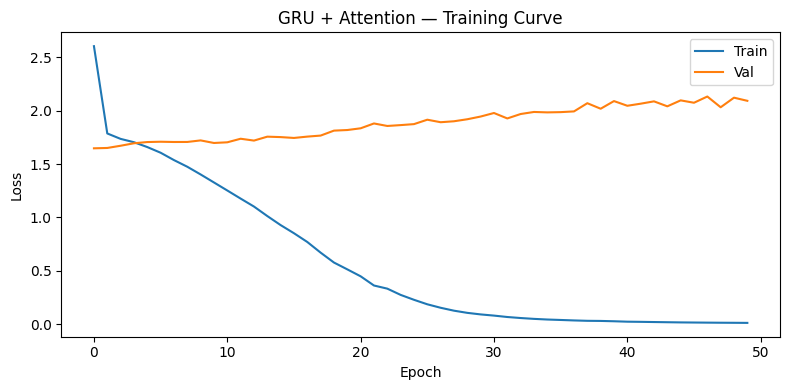

Best val loss: 1.6470


In [21]:
def run_epoch(model, loader, optimizer=None, teacher_forcing_ratio=0.5):
    """Run one epoch. If optimizer is None, runs in eval mode (no gradients)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0

    with torch.set_grad_enabled(is_train):
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(DEVICE), tgt_in.to(DEVICE), tgt_out.to(DEVICE)
            logits = model(src, tgt_in, teacher_forcing_ratio)
            seq_len = min(logits.size(1), tgt_out.size(1)) #edit from loss..

            loss = criterion(
               logits[:, :seq_len].reshape(-1, VOCAB_SIZE),
                  tgt_out[:, :seq_len].reshape(-1)
)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
                optimizer.step()

            total_loss += loss.item()

    return total_loss / len(loader)


train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, optimizer, TEACHER_FORCING_RATIO)
    val_loss   = run_epoch(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  Train: {train_loss:.4f}  Val: {val_loss:.4f}')

# Plot
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU + Attention — Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('gru_training_curve.png', dpi=150)
plt.show()
print(f'Best val loss: {best_val_loss:.4f}')